# 🩺 학생 건강상태 분류 — EDA & 파생변수 설계

**Kaggle Playground S6E7 / 팀 프로젝트 · 전처리·모델링 담당용**

---

## 이 노트북의 목표

1. **데이터를 이해한다** — 결측치, 분포, 타깃과의 관계를 통계적으로 확인한다  
2. **근거 있는 파생변수를 만든다** — “느낌”이 아니라 도메인 지식과 검증을 바탕으로 만든다  
3. **파생변수가 실제로 도움이 되는지 검증한다** — 만들었다고 끝내지 않는다  

## 왜 이 순서인가? (사고의 틀)

> 좋은 모델은 좋은 알고리즘이 아니라 **좋은 이해**에서 나온다.

- 결측치가 **정보를 담고 있는지** 먼저 확인한다 → 단순히 채우면 중요한 신호를 잃을 수 있다  
- 어떤 변수가 타깃을 **잘 구분하는지** 통계적으로 확인한다 → 파생변수 아이디어의 근거가 된다  
- 파생변수는 **검증**을 통해 채택하거나 기각한다 → 근거 없는 변수는 노이즈만 늘린다  

## 알고가자

> “파생변수가 모델 성능에 큰 영향을 줄까?”  
> → 이 데이터에서는 **중간 정도의 효과**를 기대하는 것이 현실적이다.

- 이런 합성(synthetic) 태블러 데이터와 트리 모델 조합에서는 가장 큰 점수 상승이 보통 다음 요소에서 나온다.  
  ① 로지스틱 회귀 대신 **강한 부스팅 모델(HistGradientBoosting, LightGBM 등)** 을 사용한다.  
  ② **클래스 불균형과 3분류 구조**를 적절히 다룬다.  
  ③ 신뢰할 수 있는 **교차검증(CV)** 으로 모델을 평가한다.  

- 파생변수는 그다음 단계에서 성능을 더 끌어올리는 작업이다. 다만 **서열 인코딩**과 **복합 위험점수** 같은 변수는 트리 모델에서 효과를 보이는 경우가 많다.  
- 따라서 이 과정(EDA 및 FE)에서는 파생변수를 **만들고 → 검증**하여, 실제로 성능 향상에 기여하는 변수만 남긴다.

## 0. 라이브러리 & 환경 설정

- `scipy.stats`: 통계 검정(Kruskal-Wallis, Chi-square)에 사용
- `seaborn`: 시각화
- 한글 폰트: Colab은 기본적으로 한글이 깨집니다(□□□). 아래에서 나눔폰트를 설치·등록


In [1]:
# (선택) Colab에서 한글 폰트 설치 — 처음 1회만. 이미 있으면 넘어갑니다.
# 설치 후에는 '런타임 다시 시작'이 필요할 수 있습니다.
import os
try:
    import matplotlib.font_manager as fm
    if not any('Nanum' in f.name for f in fm.fontManager.ttflist):
        os.system('apt-get -qq -y install fonts-nanum > /dev/null 2>&1')
        for fp in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
            fm.fontManager.addfont(fp)
except Exception as e:
    print('폰트 설치 스킵:', e)


In [2]:
import time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 한글 폰트 적용 (없으면 기본 폰트)
try:
    import matplotlib.font_manager as fm
    if any('Nanum' in f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = 'NanumGothic'
except Exception:
    pass
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'][0] if isinstance(plt.rcParams['font.family'], list) else plt.rcParams['font.family'])
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('준비 완료 ✅  | pandas', pd.__version__)


준비 완료 ✅  | pandas 2.2.2


## 1. 데이터 로드 & 컬럼 정의

- 팀 드라이브 경로를 그대로 사용 (베이스라인과 동일)
- 수치형/범주형을 나눠 두면 이후 EDA·전처리에서 반복 사용하기 편함


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/kaggle_student_classification/'

train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
sample_submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')

TARGET = 'health_condition'
ID = 'id'

numeric_features = ['sleep_duration','heart_rate','bmi','calorie_expenditure',
                    'step_count','exercise_duration','water_intake']
categorical_features = ['diet_type','stress_level','sleep_quality',
                        'physical_activity_level','smoking_alcohol','gender']
feature_cols = numeric_features + categorical_features

print('train:', train.shape, '| test:', test.shape)
print('\n타깃 클래스 분포:')
print(train[TARGET].value_counts())
print('\n비율:')
print(train[TARGET].value_counts(normalize=True).round(4))
train.head()


train: (690088, 15) | test: (295753, 14)

타깃 클래스 분포:
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

비율:
health_condition
at-risk     0.859
unhealthy   0.084
fit         0.058
Name: proportion, dtype: float64


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.220,70.600,25.660,"2,174.000","1,326.000",19.800,1.860,veg,high,average,sedentary,yes,female
1,1,at-risk,5.530,71.300,25.840,"1,966.000","9,891.000",49.900,1.260,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.290,75.400,24.540,"2,688.000","14,216.000",38.100,1.600,veg,high,poor,active,yes,male
3,3,unhealthy,4.700,77.200,23.130,"2,630.000","7,174.000",59.900,2.020,veg,high,average,active,occasional,female
4,4,at-risk,7.230,73.400,28.440,"2,560.000","6,584.000",46.000,2.250,veg,NaN,average,sedentary,NaN,male


## 2. 첫인상 (describe / dtypes / 카디널리티)

**볼 포인트**
- 수치형: 값의 범위가 상식적인가? (예: BMI가 음수/1000이면 이상치·오류 의심)
- 범주형: 카테고리 개수(cardinality)가 몇 개인가? 오타로 인한 유령 카테고리는 없나?


In [5]:
display(train[numeric_features].describe().T)
print('\n[범주형 고유값 개수 & 값]')
for c in categorical_features:
    print(f'- {c:24s} ({train[c].nunique()}개):', sorted(train[c].dropna().unique().tolist()))


,count,mean,std,min,25%,50%,75%,max
sleep_duration,"614,089.000",6.993,1.215,3.000,6.160,6.990,7.810,10.000
heart_rate,"682,255.000",75.097,8.175,50.000,69.400,75.100,80.700,107.700
bmi,"676,190.000",22.985,2.482,16.000,21.320,22.990,24.660,34.820
calorie_expenditure,"637,235.000","2,226.085",347.532,"1,200.000","2,053.000","2,241.000","2,456.000","3,580.000"
step_count,"676,172.000","8,615.953","3,929.400","1,002.000","5,389.000","8,856.000","12,114.000","14,999.000"
exercise_duration,"683,187.000",38.751,14.742,0.000,29.200,39.400,49.400,99.800
water_intake,"646,611.000",2.189,0.518,0.500,1.840,2.170,2.500,4.720



[범주형 고유값 개수 & 값]
- diet_type                (3개): ['balanced', 'non-veg', 'veg']
- stress_level             (3개): ['high', 'low', 'medium']
- sleep_quality            (3개): ['average', 'good', 'poor']
- physical_activity_level  (3개): ['active', 'moderate', 'sedentary']
- smoking_alcohol          (3개): ['no', 'occasional', 'yes']
- gender                   (3개): ['female', 'male', 'other']


## 3. 타깃 분석 — 심한 불균형

`at-risk`가 **약 86%**입니다. 이게 왜 중요할까?

> - 아무 생각 없이 전부 `at-risk`로 찍어도 **정확도(accuracy) 86%**가 나옴 → accuracy는 여기서 **거의 무의미**.
> - 그래서 대회/베이스라인은 **balanced accuracy**(각 클래스 recall의 평균)와 **macro-F1**을 본다.
> - 모델 학습 때도 소수 클래스(fit, unhealthy)를 놓치지 않도록 `class_weight='balanced'` 같은 장치가 필요


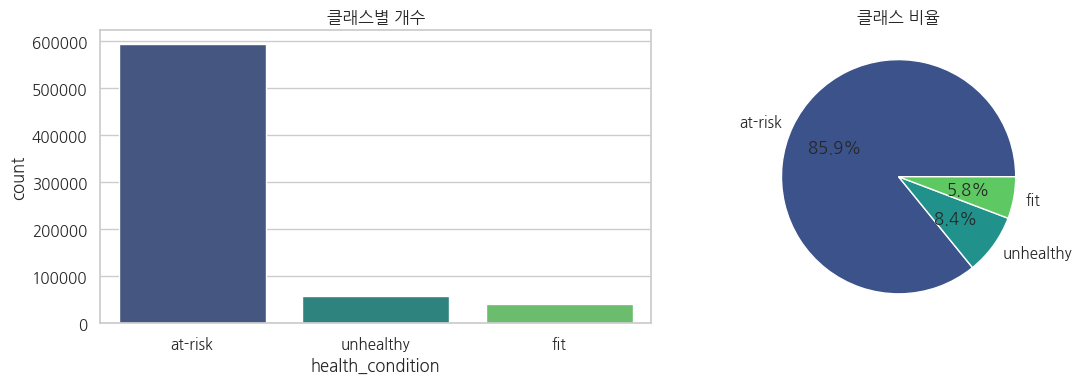

In [6]:
vc = train[TARGET].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=vc.index, y=vc.values, ax=ax[0], palette='viridis')
ax[0].set_title('클래스별 개수'); ax[0].set_ylabel('count')
ax[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', 3))
ax[1].set_title('클래스 비율')
plt.tight_layout(); plt.show()


## 4. 결측치 분석 ⭐ (현재 프로세스에서 가장 중요한 파트 중 하나)

결측치는 그냥 "채워야 할 빈칸"이 아니다. **결측 자체가 신호일 수 있음**

- **MCAR** (완전 무작위 결측): 정말 랜덤 → 그냥 채우면 됨
- **MAR / MNAR** (조건부·비무작위 결측): 결측 여부가 타깃과 연관 → **"결측 표시자(missing indicator)"** 를 만들면 정보를 살릴 수 있음

**전략**: 각 변수에 대해 "값이 결측인 그룹"과 "값이 있는 그룹"의 **타깃 분포가 다른지** 비교
많이 다르면 → 그 변수의 결측은 정보를 담고 있으니 **결측 지표 변수**로 만들 가치가 있음.


,train_결측수,train_결측률(%),test_결측률(%)
stress_level,82811,12.000,12.000
sleep_duration,75999,11.010,11.010
sleep_quality,58331,8.450,8.450
calorie_expenditure,52853,7.660,7.660
water_intake,43477,6.300,6.300
physical_activity_level,36621,5.310,5.310
smoking_alcohol,28582,4.140,4.140
gender,21373,3.100,3.100
step_count,13916,2.020,2.020
bmi,13898,2.010,2.010


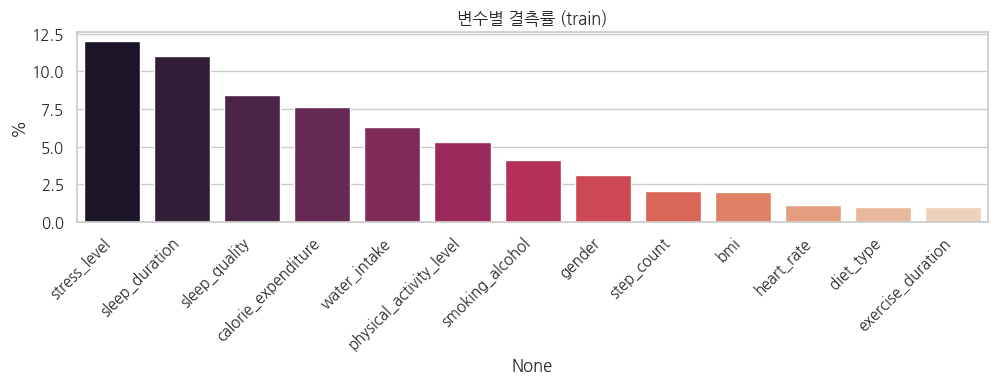

In [7]:
miss = pd.DataFrame({
    'train_결측수': train[feature_cols].isnull().sum(),
    'train_결측률(%)': (train[feature_cols].isnull().mean()*100).round(2),
    'test_결측률(%)': (test[feature_cols].isnull().mean()*100).round(2),
}).sort_values('train_결측률(%)', ascending=False)
display(miss)

plt.figure(figsize=(10,4))
sns.barplot(x=miss.index, y=miss['train_결측률(%)'], palette='rocket')
plt.xticks(rotation=45, ha='right'); plt.title('변수별 결측률 (train)'); plt.ylabel('%')
plt.tight_layout(); plt.show()


In [8]:
# ⭐ 결측이 '정보'인지 검정: 결측 여부(그룹) vs 타깃  → Chi-square
# p-value가 아주 작으면(<0.05) "결측 여부와 타깃이 독립이 아니다" = 결측에 신호가 있다
rows = []
for c in feature_cols:
    if train[c].isnull().sum() == 0:
        continue
    is_miss = train[c].isnull()
    ct = pd.crosstab(is_miss, train[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    # 결측 그룹의 소수클래스(unhealthy) 비율 vs 비결측 그룹
    rate_miss = (train.loc[is_miss, TARGET]=='unhealthy').mean()
    rate_ok   = (train.loc[~is_miss, TARGET]=='unhealthy').mean()
    rows.append({'feature':c, 'chi2':chi2, 'p_value':p,
                 'unhealthy율(결측)':rate_miss, 'unhealthy율(정상)':rate_ok})
miss_signal = pd.DataFrame(rows).sort_values('chi2', ascending=False)
miss_signal['결측이_정보?'] = np.where(miss_signal['p_value']<0.05, '✅ 있음', '— 약함')
display(miss_signal.round(4))
print('\n해석: chi2가 크고 p<0.05인 변수는 결측 지표(_isna)를 만들 가치가 있습니다.')


,feature,chi2,p_value,unhealthy율(결측),unhealthy율(정상),결측이_정보?
2,bmi,660.986,0.000,0.029,0.085,✅ 있음
1,heart_rate,11.114,0.004,0.074,0.084,✅ 있음
7,diet_type,6.610,0.037,0.082,0.084,✅ 있음
6,water_intake,6.497,0.039,0.087,0.083,✅ 있음
5,exercise_duration,3.517,0.172,0.089,0.084,— 약함
12,gender,3.048,0.218,0.086,0.084,— 약함
9,sleep_quality,1.978,0.372,0.082,0.084,— 약함
4,step_count,1.581,0.454,0.081,0.084,— 약함
11,smoking_alcohol,1.404,0.496,0.086,0.084,— 약함
0,sleep_duration,0.322,0.851,0.083,0.084,— 약함



해석: chi2가 크고 p<0.05인 변수는 결측 지표(_isna)를 만들 가치가 있습니다.


### 결측치 처리 방침 (요약)
- **채우기(impute)**: 수치형=중앙값, 범주형=최빈값 (베이스라인과 동일, 파이프라인에서 처리)
- **결측 지표 추가**: 위에서 `p<0.05`로 나온 변수는 `변수_isna` 이진 변수를 추가 (8번 파트에서 생성)
- 트리 모델(HistGradientBoosting/LightGBM)은 **결측을 그대로 학습**할 수도 있음 → 나중에 실험으로 비교해볼 것


## 5. 수치형 변수 — 분포 & 타깃별 차이

**볼 포인트**
1. 분포 모양 (치우침, 다봉성, 이상치)
2. **타깃 클래스별로 값이 다른가?** → 다르면 예측에 유용한 변수

무거운 그래프는 5만 건만 **층화 샘플링**해서 그립니다 (69만 건 전부 그리면 느리고 점이 뭉개짐).


시각화 샘플 크기: 51000


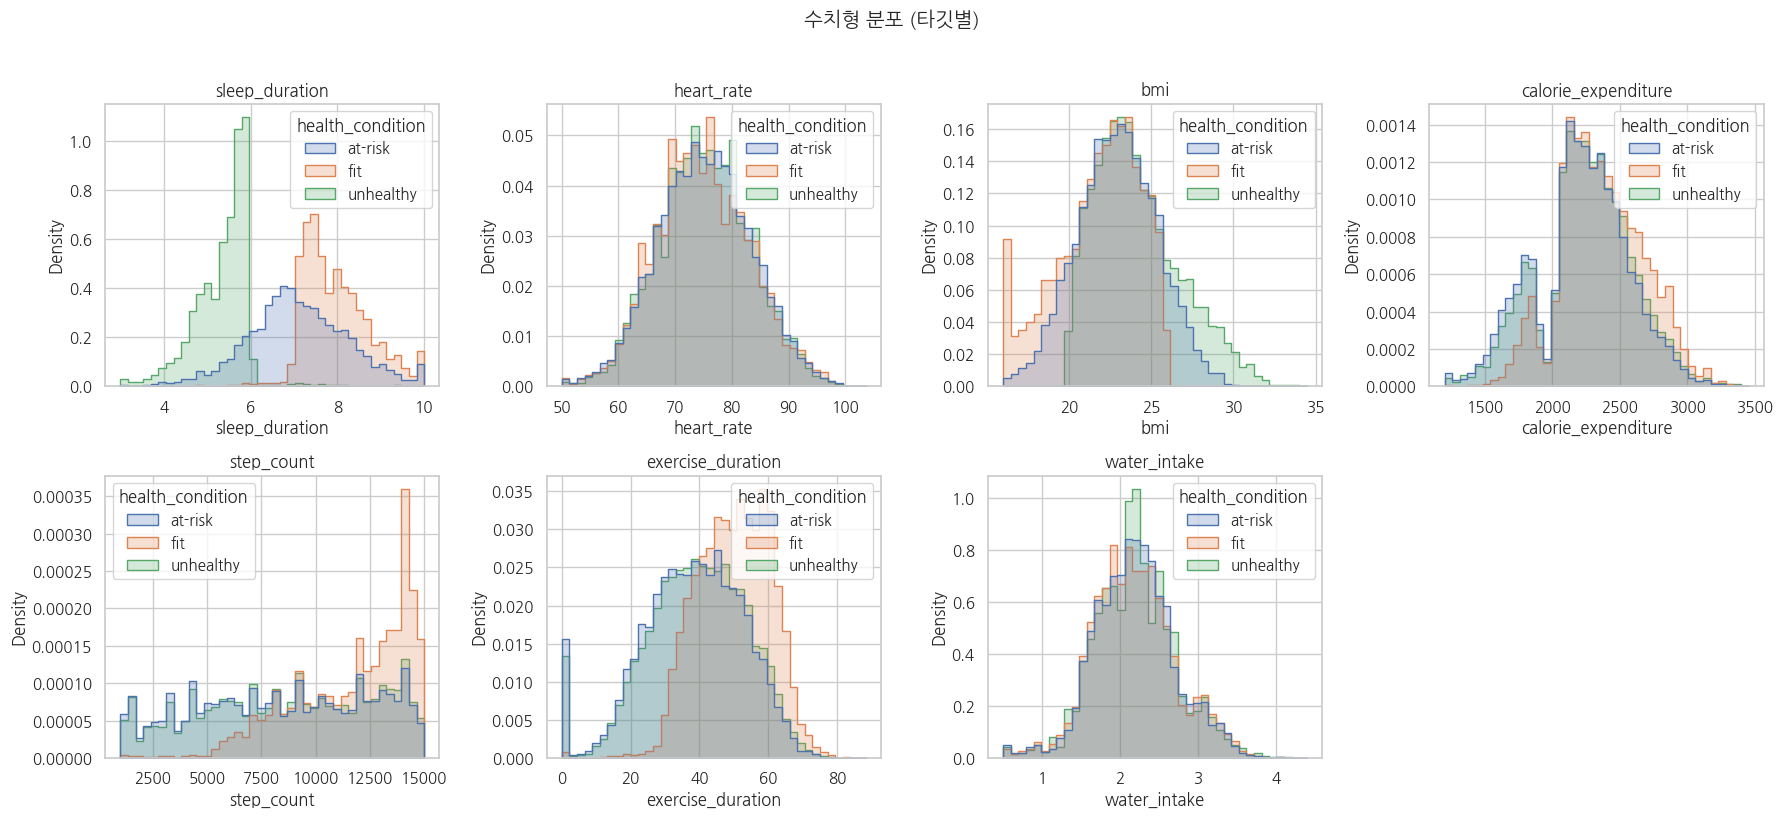

In [9]:
# 시각화용 층화 샘플 (속도)
plot_sample = train.groupby(TARGET, group_keys=False).apply(
    lambda s: s.sample(min(len(s), 17000), random_state=RANDOM_STATE))
print('시각화 샘플 크기:', len(plot_sample))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.ravel(), numeric_features):
    sns.histplot(data=plot_sample, x=c, hue=TARGET, bins=40, stat='density',
                 common_norm=False, element='step', ax=ax)
    ax.set_title(c)
for ax in axes.ravel()[len(numeric_features):]:
    ax.axis('off')
plt.suptitle('수치형 분포 (타깃별)', y=1.02); plt.tight_layout(); plt.show()


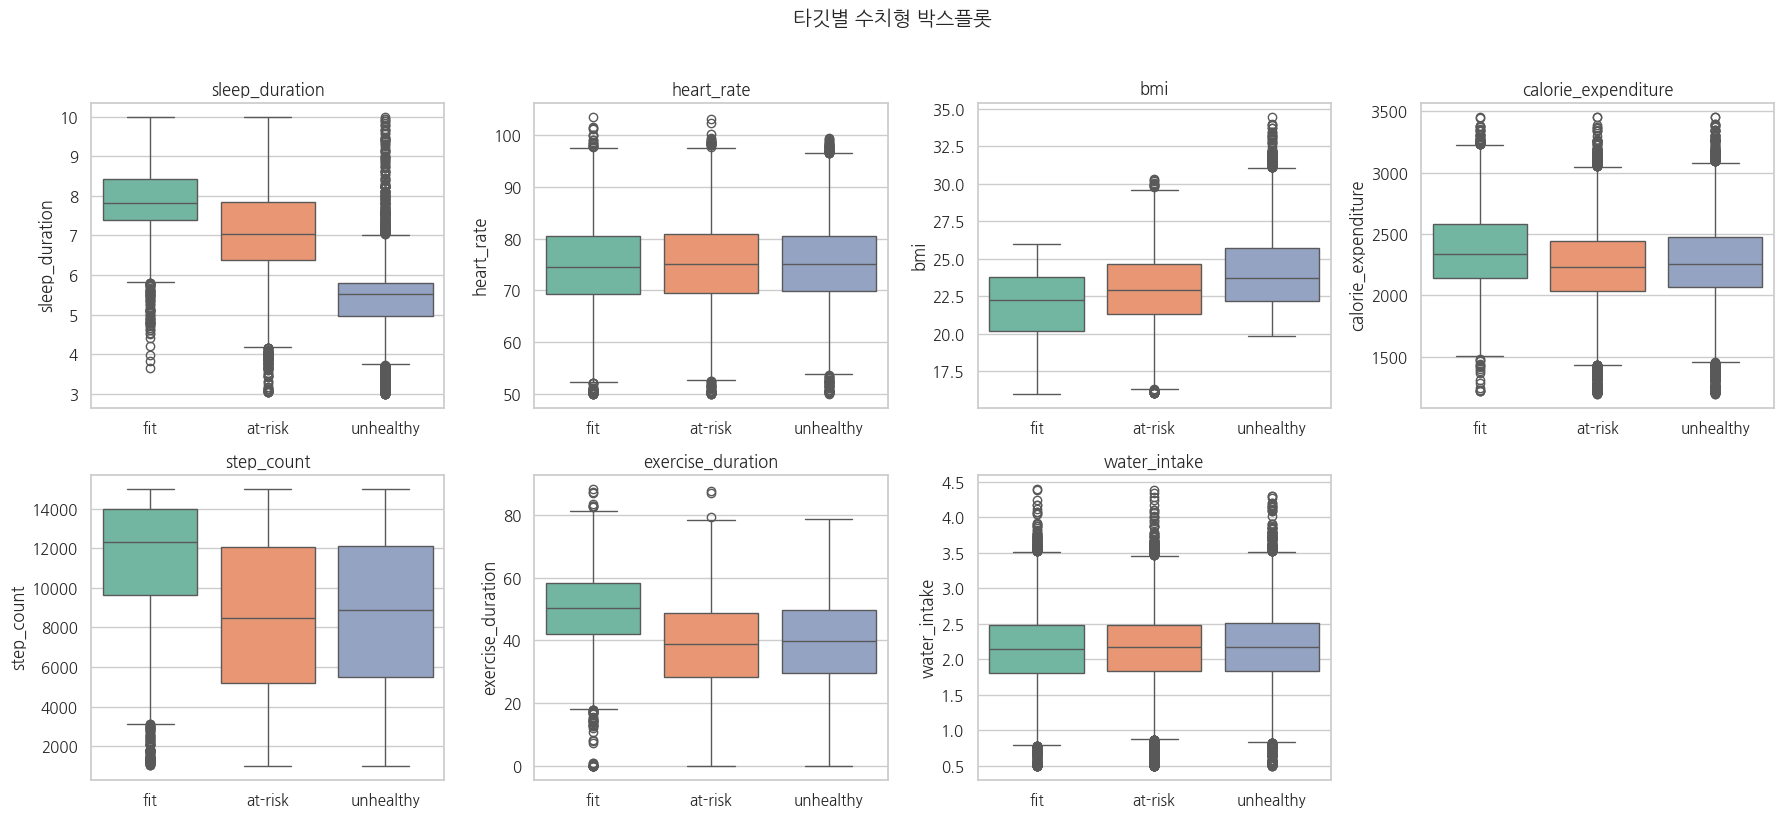

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
order = ['fit','at-risk','unhealthy']
for ax, c in zip(axes.ravel(), numeric_features):
    sns.boxplot(data=plot_sample, x=TARGET, y=c, order=order, ax=ax, palette='Set2')
    ax.set_title(c); ax.set_xlabel('')
for ax in axes.ravel()[len(numeric_features):]:
    ax.axis('off')
plt.suptitle('타깃별 수치형 박스플롯', y=1.02); plt.tight_layout(); plt.show()


In [11]:
# Kruskal-Wallis 검정: '세 클래스 간 이 변수의 분포가 다른가?'
# 왜 ANOVA 대신 KW? → 정규성/등분산 가정에 덜 민감한 비모수 검정이라 안전.
# H가 클수록 클래스 구분력이 큼. eta2로 효과크기도 계산.
rows = []
for c in numeric_features:
    groups = [train.loc[train[TARGET]==g, c].dropna() for g in order]
    H, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    eta2 = (H - (len(order)-1)) / (n - len(order))   # 근사 효과크기
    rows.append({'feature':c, 'H(kruskal)':H, 'p_value':p, 'eta2(효과크기)':max(eta2,0)})
kw = pd.DataFrame(rows).sort_values('H(kruskal)', ascending=False)
display(kw.round(4))
print('해석: H가 크고 p<0.05면 그 변수는 타깃을 잘 가릅니다. eta2는 실질적 크기(0.01소/0.06중/0.14대).')


,feature,H(kruskal),p_value,eta2(효과크기)
0,sleep_duration,"119,475.238",0.000,0.195
5,exercise_duration,"26,244.430",0.000,0.038
4,step_count,"25,904.553",0.000,0.038
2,bmi,"13,329.348",0.000,0.020
3,calorie_expenditure,"5,532.373",0.000,0.009
1,heart_rate,102.971,0.000,0.000
6,water_intake,37.449,0.000,0.000


해석: H가 크고 p<0.05면 그 변수는 타깃을 잘 가릅니다. eta2는 실질적 크기(0.01소/0.06중/0.14대).


## 6. 범주형 변수 — 타깃과의 관계

- 각 카테고리별 **타깃 비율** 확인 (예: 흡연/음주 'yes'에서 unhealthy 비율이 높은가?)
- **Chi-square 검정**으로 독립성(=관계 없음)을 검정하고, **Cramér's V**로 관계의 세기를 봄
  - p-value는 표본이 크면 거의 항상 유의(작음)하게 나옴 → 그래서 **효과크기(Cramér's V)** 를 같이 봐야 함.


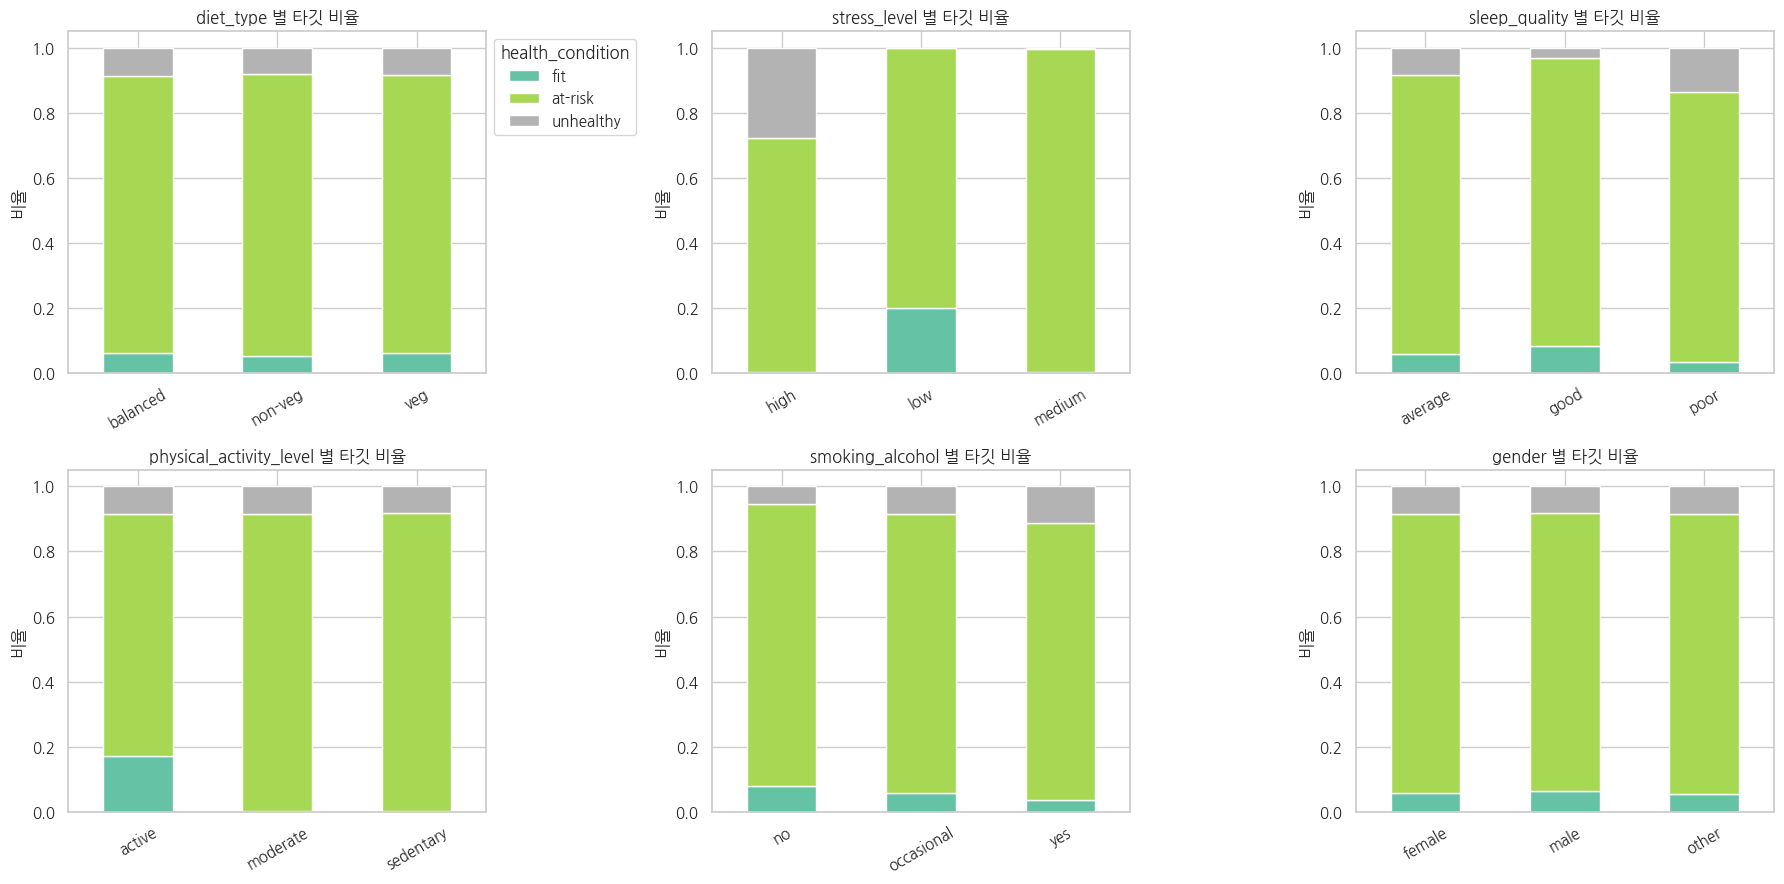

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, c in zip(axes.ravel(), categorical_features):
    ct = pd.crosstab(train[c], train[TARGET], normalize='index')[order]
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', legend=False)
    ax.set_title(f'{c} 별 타깃 비율'); ax.set_xlabel(''); ax.set_ylabel('비율')
    ax.tick_params(axis='x', rotation=30)
axes.ravel()[0].legend(order, title=TARGET, bbox_to_anchor=(1.0,1.0))
plt.tight_layout(); plt.show()


In [13]:
def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2corr / max(min(kcorr-1, rcorr-1), 1e-9))

rows = []
for c in categorical_features:
    ct = pd.crosstab(train[c], train[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    rows.append({'feature':c, 'chi2':chi2, 'p_value':p, "Cramér's V":cramers_v(ct)})
cat_assoc = pd.DataFrame(rows).sort_values("Cramér's V", ascending=False)
display(cat_assoc.round(4))
print("해석: Cramér's V (0~1). 0.1↑ 약함 / 0.3↑ 중간 / 0.5↑ 강함. 이 값이 큰 변수가 예측에 중요.")


,feature,chi2,p_value,Cramér's V
1,stress_level,"206,618.522",0.000,0.412
3,physical_activity_level,"75,816.235",0.000,0.241
2,sleep_quality,"18,269.831",0.000,0.120
4,smoking_alcohol,"7,715.699",0.000,0.076
0,diet_type,323.111,0.000,0.015
5,gender,227.817,0.000,0.013


해석: Cramér's V (0~1). 0.1↑ 약함 / 0.3↑ 중간 / 0.5↑ 강함. 이 값이 큰 변수가 예측에 중요.


## 7. 수치형 상관관계 (다중공선성 점검)

- 수치형끼리 강하게 상관되면(|r|>0.8) 정보가 중복 → 로지스틱 회귀에선 계수 불안정.
- 트리 모델은 다중공선성에 강하지만, **파생변수를 만들 때 "이미 있는 정보의 재탕"인지** 확인하는 용도


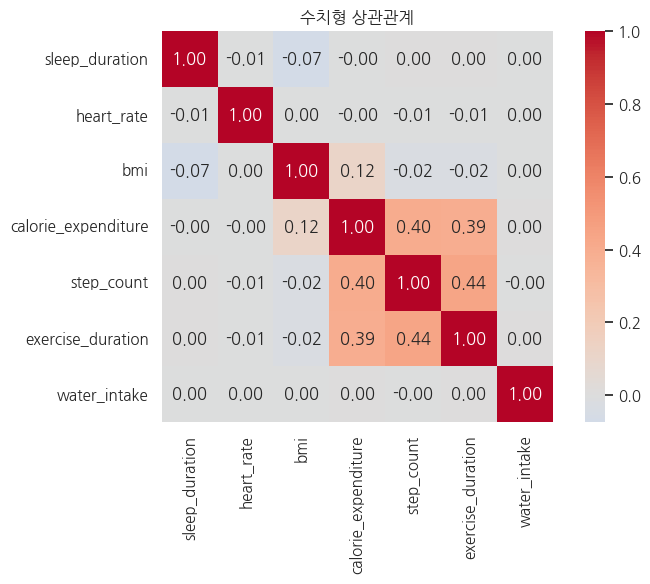

In [14]:
corr = train[numeric_features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('수치형 상관관계'); plt.tight_layout(); plt.show()


## 8. 파생변수 설계 ⭐⭐ (핵심)

앞의 EDA/도메인 지식을 근거로 파생변수를 만듭니다. **각 변수에 '왜'가 있어야** 함

| 파생변수 | 아이디어(근거) |
|---|---|
| **서열 인코딩** `*_ord` | stress/sleep_quality/activity/smoking은 **순서가 있는** 범주. OneHot보다 서열 숫자가 트리 모델에 유리하고 차원↓ |
| `sleep_debt`, `sleep_ideal` | 건강 기준 수면 7~9h. **부족분**과 **이상범위 여부**가 fit/unhealthy를 가르는 핵심 |
| `bmi_cat`, `bmi_abnormal` | WHO BMI 구간(저체중/정상/과체중/비만). '비정상 체중'이 위험 신호 |
| `hr_high` | 안정시 심박수 높음 = 위험 신호(대략 >90 이상 표시) |
| `steps_per_ex_min`, `cal_per_step`, `low_activity` | 활동의 **효율/강도**. 단순 걸음수보다 조합이 생활패턴을 잘 표현 |
| `low_water` | 수분 섭취 부족 플래그 |
| **`lifestyle_risk_score`** ⭐ | 위험요인 개수 합산(수면부족·고스트레스·수면질나쁨·좌식·저활동·흡연음주·비정상BMI). **타깃이 규칙기반이면 이 한 변수가 매우 강력**할 수 있음 |
| `n_missing`, `*_isna` | 4번에서 '결측이 정보'로 나온 변수의 결측 지표 |

> ⚠️ **데이터 누수 주의**: 파생변수는 **오직 피처만** 사용해서 만듭니다(타깃 사용 금지).
> 그리고 train에서 정한 기준(중앙값/분위수 등)을 **test에도 동일하게** 적용해야함 -> 매우 중요!!!


In [15]:
# --- train 기준으로 임계값(분위수 등)을 먼저 계산해 둡니다 (test 누수 방지) ---
HR_HI   = train['heart_rate'].quantile(0.75)          # 심박수 상위 25%를 '높음'
STEP_LO = train['step_count'].quantile(0.25)          # 걸음수 하위 25%를 '저활동'
WATER_LO= train['water_intake'].quantile(0.25)        # 물 섭취 하위 25%

# 서열(순서형) 매핑 — 값이 없거나 오타면 NaN
ord_maps = {
    'stress_level':            {'low':0, 'medium':1, 'high':2},
    'sleep_quality':           {'poor':0, 'average':1, 'good':2},
    'physical_activity_level': {'sedentary':0, 'moderate':1, 'active':2},
    'smoking_alcohol':         {'no':0, 'occasional':1, 'yes':2},
}
# 결측이 '정보'로 나온 변수 목록 (4번 결과 기반, 필요시 조정)
isna_cols = feature_cols  # 일단 전부 후보로 만들고, 검증에서 취사선택

def make_features(df):
    X = df.copy()

    # 1) 서열 인코딩
    for col, m in ord_maps.items():
        X[col + '_ord'] = X[col].map(m)

    # 2) 수면
    X['sleep_debt']  = (7 - X['sleep_duration']).clip(lower=0)          # 7시간 미만 부족분
    X['sleep_excess']= (X['sleep_duration'] - 9).clip(lower=0)          # 9시간 초과분
    X['sleep_ideal'] = X['sleep_duration'].between(7, 9).astype('float')# 이상범위=1
    X.loc[X['sleep_duration'].isna(), 'sleep_ideal'] = np.nan

    # 3) BMI (WHO 구간)  0저체중 1정상 2과체중 3비만
    X['bmi_cat'] = pd.cut(X['bmi'], bins=[-np.inf,18.5,25,30,np.inf], labels=[0,1,2,3]).astype('float')
    X['bmi_abnormal'] = (~X['bmi'].between(18.5, 25)).astype('float')
    X.loc[X['bmi'].isna(), 'bmi_abnormal'] = np.nan

    # 4) 심박수
    X['hr_high'] = (X['heart_rate'] > HR_HI).astype('float')
    X.loc[X['heart_rate'].isna(), 'hr_high'] = np.nan

    # 5) 활동 효율/강도
    X['steps_per_ex_min'] = X['step_count'] / (X['exercise_duration'] + 1)
    X['cal_per_step']     = X['calorie_expenditure'] / (X['step_count'] + 1)
    X['low_activity']     = (X['step_count'] < STEP_LO).astype('float')
    X.loc[X['step_count'].isna(), 'low_activity'] = np.nan
    X['low_water']        = (X['water_intake'] < WATER_LO).astype('float')
    X.loc[X['water_intake'].isna(), 'low_water'] = np.nan

    # 6) ⭐ 복합 라이프스타일 위험점수 (위험요인 개수 합, 결측은 0으로 간주해 합산)
    risk = pd.DataFrame(index=X.index)
    risk['r_sleep']   = (X['sleep_duration'] < 6).astype(float)
    risk['r_stress']  = (X['stress_level'] == 'high').astype(float)
    risk['r_sleepq']  = (X['sleep_quality'] == 'poor').astype(float)
    risk['r_sed']     = (X['physical_activity_level'] == 'sedentary').astype(float)
    risk['r_lowstep'] = (X['step_count'] < STEP_LO).astype(float)
    risk['r_smoke']   = (X['smoking_alcohol'] == 'yes').astype(float)
    risk['r_bmi']     = (~X['bmi'].between(18.5, 25)).astype(float)
    X['lifestyle_risk_score'] = risk.sum(axis=1)

    # 7) 결측 지표
    X['n_missing'] = df[feature_cols].isnull().sum(axis=1)
    for c in isna_cols:
        X[c + '_isna'] = df[c].isnull().astype('int8')

    return X

train_fe = make_features(train)
test_fe  = make_features(test)

derived_cols = [c for c in train_fe.columns if c not in train.columns]
print(f'생성된 파생변수 {len(derived_cols)}개:')
print(derived_cols)
train_fe[['lifestyle_risk_score','sleep_debt','bmi_cat','steps_per_ex_min']].describe().T


생성된 파생변수 29개:
['stress_level_ord', 'sleep_quality_ord', 'physical_activity_level_ord', 'smoking_alcohol_ord', 'sleep_debt', 'sleep_excess', 'sleep_ideal', 'bmi_cat', 'bmi_abnormal', 'hr_high', 'steps_per_ex_min', 'cal_per_step', 'low_activity', 'low_water', 'lifestyle_risk_score', 'n_missing', 'sleep_duration_isna', 'heart_rate_isna', 'bmi_isna', 'calorie_expenditure_isna', 'step_count_isna', 'exercise_duration_isna', 'water_intake_isna', 'diet_type_isna', 'stress_level_isna', 'sleep_quality_isna', 'physical_activity_level_isna', 'smoking_alcohol_isna', 'gender_isna']


,count,mean,std,min,25%,50%,75%,max
lifestyle_risk_score,"690,088.000",1.905,1.316,0.000,1.000,2.000,3.000,7.000
sleep_debt,"614,089.000",0.488,0.712,0.000,0.000,0.010,0.840,4.000
bmi_cat,"676,190.000",1.174,0.469,0.000,1.000,1.000,1.000,3.000
steps_per_ex_min,"669,402.000",374.575,979.995,20.000,147.724,219.130,293.317,"12,387.000"


## 9. 파생변수 검증 — "만들었으면 정말 영향이 있는지 증명하자"

두 가지로 확인

1. **상호정보량(Mutual Information)**: 각 변수가 타깃과 얼마나 정보를 공유하는지 (모델 독립적). 파생변수들이 상위권에 드는지 확인
2. **리프트 테스트 (모델 2종 교차검증)**: 원본 변수만 vs 원본+파생 을 같은 조건에서 CV로 비교 → **실제 점수가 오르는지**.
   - **HistGradientBoosting** + **LightGBM** 두 모델로 동시에 확인
   - 왜 2개? → **두 모델 모두에서 오르면** 그 상승이 특정 모델의 우연이 아니라 **진짜**라고 신뢰 가능(교차검증).

> HistGradientBoosting은 sklearn 내장 부스팅(LightGBM급 성능 + 결측 자동 처리). LightGBM은 아래 `!pip install lightgbm`으로 설치되며,
> 설치가 안 되면 자동으로 HistGradientBoosting만 사용


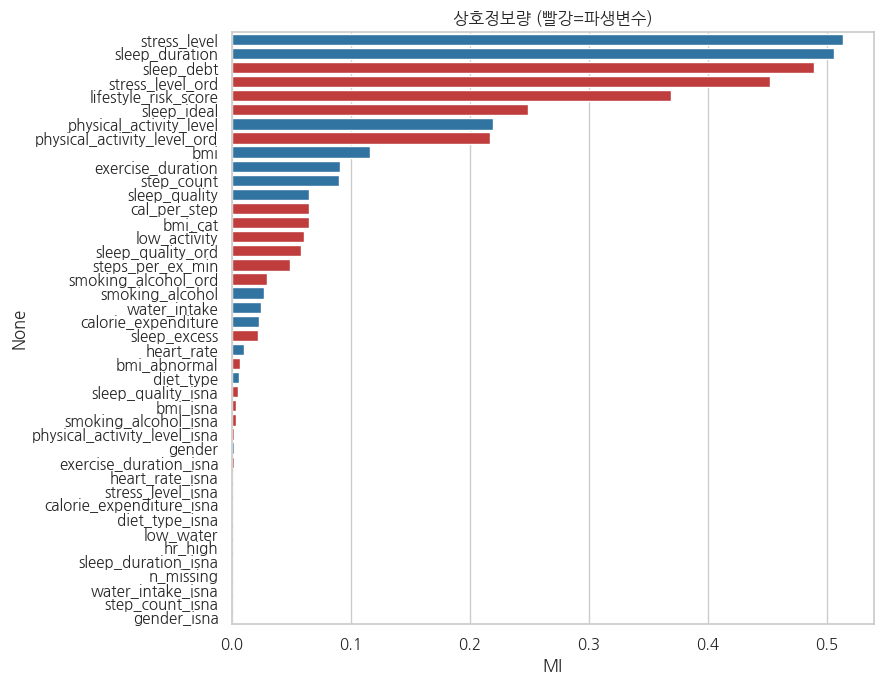

,MI
stress_level,0.514
sleep_duration,0.506
sleep_debt,0.488
stress_level_ord,0.452
lifestyle_risk_score,0.369
sleep_ideal,0.249
physical_activity_level,0.219
physical_activity_level_ord,0.217
bmi,0.116
exercise_duration,0.091


In [16]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

# 검증용 층화 샘플 (속도)
val_sample = train_fe.groupby(TARGET, group_keys=False).apply(
    lambda s: s.sample(min(len(s), 20000), random_state=RANDOM_STATE))
y_s = val_sample[TARGET]

def build_matrix(df, include_derived=True):
    num = numeric_features + ([c for c in derived_cols] if include_derived else [])
    num = [c for c in num if df[c].dtype != 'object']
    cat = categorical_features
    Xn = df[num].copy()
    Xn = Xn.fillna(Xn.median(numeric_only=True))
    Xc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(
            df[cat].astype(str))
    Xc = pd.DataFrame(Xc, columns=cat, index=df.index)
    return pd.concat([Xn, Xc], axis=1)

Xmi = build_matrix(val_sample, include_derived=True)
mi = mutual_info_classif(Xmi, y_s, random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=Xmi.columns).sort_values(ascending=False)

plt.figure(figsize=(9,7))
colors = ['#d62728' if c in derived_cols else '#1f77b4' for c in mi_s.index]
sns.barplot(x=mi_s.values, y=mi_s.index, palette=colors)
plt.title('상호정보량 (빨강=파생변수)'); plt.xlabel('MI'); plt.tight_layout(); plt.show()
display(mi_s.round(4).to_frame('MI').head(15))


In [17]:
# LightGBM을 쓰려면 Colab에서 아래 한 줄 먼저 실행 (설치 안 되면 HGB만 사용)
# !pip install -q lightgbm

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['balanced_accuracy', 'f1_macro']

# 검증에 쓸 강한 모델 2종 (LightGBM은 설치돼 있으면 자동 추가)
val_models = {
    'HistGradientBoosting': HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, class_weight='balanced', max_iter=300),
}
try:
    from lightgbm import LGBMClassifier
    val_models['LightGBM'] = LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=63,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
except Exception as e:
    print('LightGBM 미설치 → HistGradientBoosting만 사용:', e)

# 각 모델 × (원본만 / 원본+파생) 조합으로 리프트 측정
rows = []
for name, model in val_models.items():
    for include_derived, label in [(False, '원본만(13)'), (True, '원본+파생')]:
        X = build_matrix(val_sample, include_derived=include_derived)
        t0 = time.time()
        r = cross_validate(clone(model), X, y_s, cv=cv, scoring=scoring, n_jobs=-1)
        rows.append({'model':name, 'feature_set':label, 'n_features':X.shape[1],
                     'balanced_acc':r['test_balanced_accuracy'].mean(),
                     'f1_macro':r['test_f1_macro'].mean(),
                     'time(s)':round(time.time()-t0, 1)})

res = pd.DataFrame(rows)
# 모델별로 '원본만' 대비 상승분 계산
res['balanced_acc_상승'] = res.groupby('model')['balanced_acc'].transform(lambda s: s - s.iloc[0])
display(res.round(4))
print('\n해석:')
print(' - 두 모델 모두 상승분이 +0.005 이상이면 파생변수 효과를 신뢰(교차검증 통과).')
print(' - 한쪽만 오르면 신중히. MI 하위권 파생변수는 최종 모델에서 빼는 것도 고려(노이즈 감소).')


,model,feature_set,n_features,balanced_acc,f1_macro,time(s),balanced_acc_상승
0,HistGradientBoosting,원본만(13),13,0.947,0.947,13.700,0.000
1,HistGradientBoosting,원본+파생,42,0.949,0.949,18.900,0.002
2,LightGBM,원본만(13),13,0.948,0.948,148.100,0.000
3,LightGBM,원본+파생,42,0.949,0.949,241.600,0.001



해석:
 - 두 모델 모두 상승분이 +0.005 이상이면 파생변수 효과를 신뢰(교차검증 통과).
 - 한쪽만 오르면 신중히. MI 하위권 파생변수는 최종 모델에서 빼는 것도 고려(노이즈 감소).


### 검증 결과 해석 가이드
- **`lifestyle_risk_score`, `*_ord`, `bmi_cat`** 이 MI 상위권이면 → 채택 확정. 트리 모델에서 특히 유용.
- 리프트가 **+0.005 이상**이면 파생변수가 의미 있게 기여한 것. 미미(±0.002)하면 "핵심 몇 개만" 남김
- **경고**: MI 하위 + 리프트 없음인 파생변수는 과감히 버리기로 함. 변수는 많다고 좋은 게 아니기 때문(노이즈·과적합).
- 이 데이터는 합성이라, 원본 변수 몇 개(수면·BMI·스트레스·활동)가 이미 강력할 가능성이 큼.
  그렇다면 파생의 역할은 "**로지스틱 같은 선형 모델을 도와주는 것**"에 가깝고, 강한 부스팅 모델에선 상대적으로 이득이 작을 수 있음


## 10. 전처리 결과 저장 (모델링 단계에서 재사용)

파생변수까지 붙인 데이터를 저장해 두면, 다음 **모델 비교 단계**에서 EDA를 굳이 다시 돌릴 필요는 없음


In [18]:
# 최종 채택할 파생변수를 여기서 고르세요 (검증 결과 반영).
# 우선 전부 저장 → 모델링 노트북에서 선택적으로 사용해도 됩니다.
save_cols_train = [ID, TARGET] + feature_cols + derived_cols
save_cols_test  = [ID] + feature_cols + derived_cols

OUT = DATA_PATH  # 같은 폴더에 저장
train_fe[save_cols_train].to_csv(OUT + 'train_fe.csv', index=False)
test_fe[save_cols_test].to_csv(OUT + 'test_fe.csv', index=False)
print('저장 완료 ✅')
print(' -', OUT + 'train_fe.csv', train_fe[save_cols_train].shape)
print(' -', OUT + 'test_fe.csv ', test_fe[save_cols_test].shape)


저장 완료 ✅
 - /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/kaggle_student_classification/train_fe.csv (690088, 44)
 - /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/kaggle_student_classification/test_fe.csv  (295753, 43)


## ✅ 정리 & 다음 단계

### 이 노트북에서 한 것
1. **결측 분석** — 결측이 정보인지 Chi-square로 검정 → 결측 지표 변수 근거 확보
2. **수치형/범주형 EDA** — Kruskal-Wallis, Chi-square, Cramér's V로 "어떤 변수가 타깃을 가르는지" 통계적으로 확인
3. **파생변수 설계** — 도메인 근거로 서열인코딩·수면·BMI·복합 위험점수 등 생성
4. **검증** — MI + HistGradientBoosting 리프트로 "정말 도움되는지" 증명하고 취사선택

### 발표자료(간지)에 그대로 쓸 수 있는 것
- 타깃 불균형 그래프 / 결측률 그래프
- Kruskal-Wallis · Chi-square · Cramér's V 표 (= "탐색적 자료분석: 시각화 및 통계 검정" 요건 충족)
- 파생변수 표 + MI 그래프 + 리프트 비교표

### 다음 단계 (모델링 노트북에서 — 프로젝트 요건)
1. **10개 이상 모델 비교표** (시간 측정 필수) — Logistic / RidgeClf / KNN / DecisionTree / RandomForest / ExtraTrees / HistGradientBoosting / (가능하면 LightGBM/XGBoost/CatBoost) / GaussianNB / LinearSVC 등
   - **샘플링 필수** (전체로 10개 돌리면 시간 초과). 층화 샘플 5만~10만으로 상대 비교.
   - **시간 대비 balanced_accuracy 산점도** 시각화 (요건)
2. **Pipeline 아키텍처** — 전처리+모델을 하나의 Pipeline/ColumnTransformer로 (요건: "머신러닝 아키텍처")
3. **상위 모델 튜닝** → 전체 데이터 학습 → `submission.csv` 생성 → 제출 (ID+점수 캡처)
4. **SCQA 서비스 기획** — 예: "건강 위험군 조기경보 → 맞춤 코칭 추천 서비스"